<h1 align="center">Predicting Credit Card Fraud</h1>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Read in the data
df = pd.read_csv('card_transdata.csv')

# Check for NA values
na_values = df.isnull().sum()
print(f"Missing values:\n{na_values}")

# Check for duplicates
duplicates = df.duplicated().value_counts()
print(f"\nDuplicate rows:\n{duplicates}")

Missing values:
distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

Duplicate rows:
False    1000000
Name: count, dtype: int64


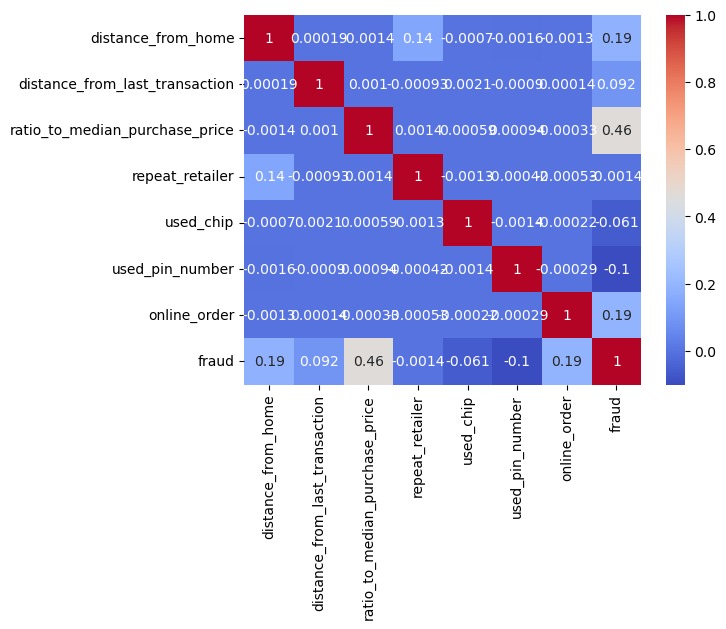

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
    
# Create and plot a correlation matrix for the data
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

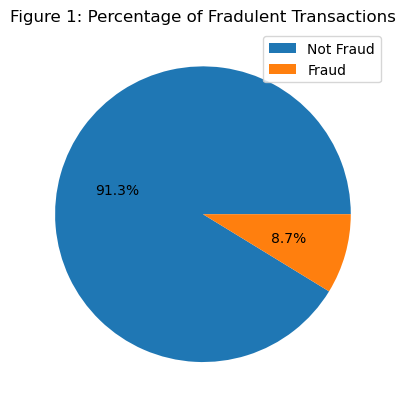

In [4]:
# Plot a pie chart showing the frequency of Fraudulent transactions in the dataset
df['fraud'].apply(lambda x: 'Fraud' if x == 1 else 'Not Fraud').value_counts().plot.pie(autopct='%1.1f%%', legend=True, labeldistance=None)
plt.ylabel('')
plt.title('Figure 1: Percentage of Fradulent Transactions')
plt.show()

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris

# Set the target and features
X = df.drop('fraud', axis=1)
y = df['fraud']

# Split into training & testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=94)

# Arguments
class_weight = 'balanced'
max_depth = 5
min_samples_split = 200
min_samples_leaf = 50
max_leaf_nodes = None

# Create a decision tree classifier
clf = DecisionTreeClassifier(
    random_state=42, 
    class_weight=class_weight,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf
)

# Train the classifier
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9967466666666667


In [6]:
from sklearn.metrics import classification_report

# Print a classification report of the data
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    273869
         1.0       0.96      1.00      0.98     26131

    accuracy                           1.00    300000
   macro avg       0.98      1.00      0.99    300000
weighted avg       1.00      1.00      1.00    300000



In [7]:
from sklearn.model_selection import cross_val_score

# run a cross validation report for the data
scores = cross_val_score(clf, X, y, cv=5) # 5-fold cross-validation
print(f"Cross-validation scores: {scores}")
print(f"Average cross-validation score: {scores.mean()}")

Cross-validation scores: [0.9967   0.99664  0.996765 0.99665  0.996455]
Average cross-validation score: 0.9966419999999999


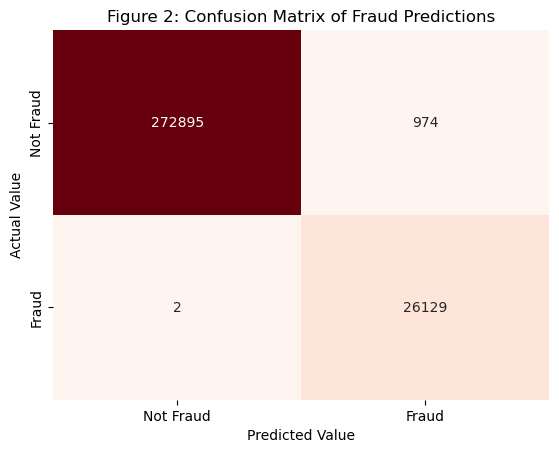

In [8]:
# Create and plot a confusion matrix
tree_matrix = confusion_matrix(y_test, y_pred)
x_labels = ['Not Fraud', 'Fraud']
y_labels = ['Not Fraud', 'Fraud']
sns.heatmap(tree_matrix, annot=True, fmt='g', cbar=None, cmap='Reds', xticklabels=x_labels, yticklabels=y_labels)
plt.ylabel('Actual Value')
plt.xlabel('Predicted Value')
plt.title('Figure 2: Confusion Matrix of Fraud Predictions')
plt.show()

In [9]:
# Plot the decision tree
plt.figure(figsize=(100, 100))
plot_tree(clf, feature_names=X.columns, class_names=['', 'Fraud'], filled=True)
plt.savefig('decision_tree.png')
plt.show()